In [4]:
import pandas as pd

ccAB_data = pd.read_csv("/app/data/yash-m2m/Data/Gene expressions/DNA_feat_TCGA_ccAB.csv", index_col="PATIENT_ID")
MYC_data = pd.read_csv("/app/data/yash-m2m/Data/Gene expressions/tcga_DNA_MYC.csv", index_col="PATIENT_ID")

In [32]:
merged_data = ccAB_data[["class_labels"]].copy()
merged_data["class_labels_MYC_V2_median"] = MYC_data["class_labels_MYC_V2_median"]

merged_data.head()

,class_labels,class_labels_MYC_V2_median
PATIENT_ID,,
TCGA.A3.3308,ccB_only,above_median
TCGA.A3.3311,NON_ccA/B,above_median
TCGA.A3.3316,ccB_only,below_median
TCGA.A3.3317,ccB_only,above_median
TCGA.A3.3320,ccA_only,below_median


Contingency Table:
class_labels_MYC_V2_median  above_median  below_median  Total
class_labels                                                 
NON_ccA/B                             16            15     31
SHARED_ccA/B                          17            19     36
ccA_only                              79            80    159
ccB_only                              84            73    157
Total                                196           187    383

Chi-squared test: χ² = 0.7093, p-value = 8.7102e-01, dof = 3
Cramér's V (association strength): 0.0430


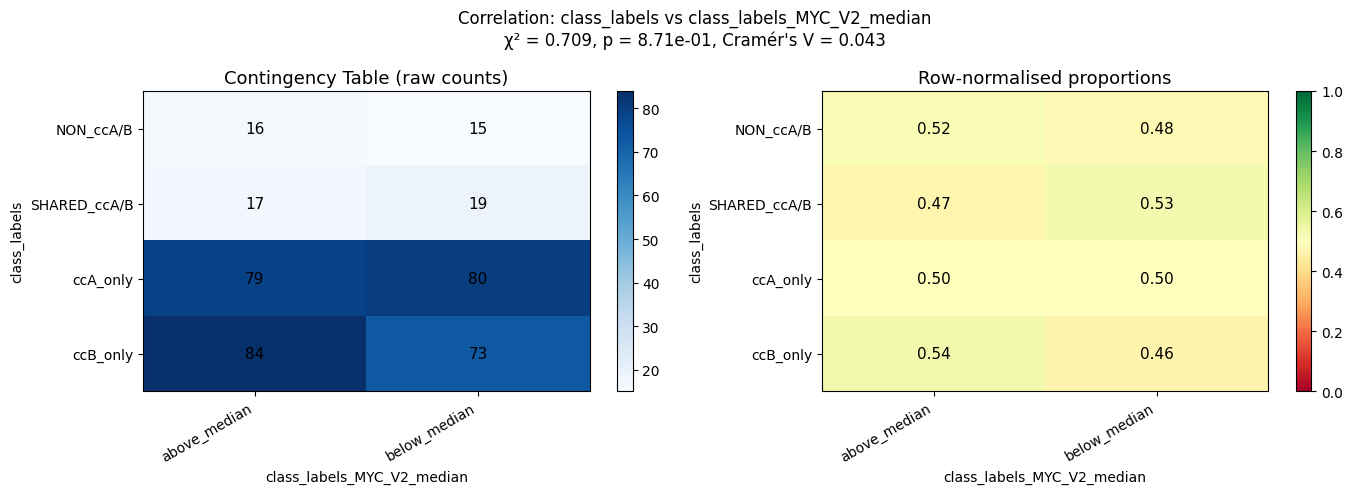

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import chi2_contingency


# --- Contingency table ---
contingency = pd.crosstab(
    merged_data["class_labels"],
    merged_data["class_labels_MYC_V2_median"],
    margins=True,
    margins_name="Total"
)
print("Contingency Table:")
print(contingency)

# --- Chi-squared test ---
ct = pd.crosstab(merged_data["class_labels"], merged_data["class_labels_MYC_V2_median"])
chi2, p_value, dof, expected = chi2_contingency(ct)
print(f"\nChi-squared test: χ² = {chi2:.4f}, p-value = {p_value:.4e}, dof = {dof}")

# --- Cramér's V ---
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"Cramér's V (association strength): {cramers_v:.4f}")

# --- Normalised heatmap ---
ct_norm = ct.div(ct.sum(axis=1), axis=0)  # row-normalise (% within each class_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts heatmap
im0 = axes[0].imshow(ct.values, cmap="Blues", aspect="auto")
axes[0].set_title("Contingency Table (raw counts)", fontsize=13)
axes[0].set_xticks(range(len(ct.columns)))
axes[0].set_xticklabels(ct.columns, rotation=30, ha="right")
axes[0].set_yticks(range(len(ct.index)))
axes[0].set_yticklabels(ct.index)
axes[0].set_xlabel("class_labels_MYC_V2_median")
axes[0].set_ylabel("class_labels")
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        axes[0].text(j, i, ct.values[i, j], ha="center", va="center",
                     color="black", fontsize=11)
plt.colorbar(im0, ax=axes[0])

# Row-normalised heatmap
im1 = axes[1].imshow(ct_norm.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
axes[1].set_title("Row-normalised proportions", fontsize=13)
axes[1].set_xticks(range(len(ct_norm.columns)))
axes[1].set_xticklabels(ct_norm.columns, rotation=30, ha="right")
axes[1].set_yticks(range(len(ct_norm.index)))
axes[1].set_yticklabels(ct_norm.index)
axes[1].set_xlabel("class_labels_MYC_V2_median")
axes[1].set_ylabel("class_labels")
for i in range(ct_norm.shape[0]):
    for j in range(ct_norm.shape[1]):
        axes[1].text(j, i, f"{ct_norm.values[i, j]:.2f}", ha="center", va="center",
                     color="black", fontsize=11)
plt.colorbar(im1, ax=axes[1])

plt.suptitle(
    f"Correlation: class_labels vs class_labels_MYC_V2_median\n"
    f"χ² = {chi2:.3f}, p = {p_value:.2e}, Cramér's V = {cramers_v:.3f}",
    fontsize=12
)
plt.tight_layout()
plt.show()